In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px 
from datetime import datetime
from tqdm import tqdm
from deepface import DeepFace
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
img_money1 = cv2.imread('data/raw_name/money_f/3284d6af-2cef-433b-b0f4-6bd9ba705bab.jpg')
img_money2 = cv2.imread('data/raw_name/money_f/85169df0-1910-4d76-b6fd-e45bee55a2a0.jpg')

In [3]:
print(f"Kích thước ảnh 1: {img_money1.shape}") 
print(f"Kích thước ảnh 2: {img_money2.shape}")

Kích thước ảnh 1: (1689, 1284, 3)
Kích thước ảnh 2: (1360, 1284, 3)


### **1. Ảnh gốc**

Ý nghĩa: (chiều cao, chiều rộng, kênh màu (Red,Green, Blue))

In [6]:
# Chuyển đổi màu từ BGR sang RGB
img_money1 = cv2.cvtColor(img_money1, cv2.COLOR_BGR2RGB)
img_money2 = cv2.cvtColor(img_money2, cv2.COLOR_BGR2RGB)

In [7]:
print(f"Kích thước ảnh 1: {img_money1.shape}") 
print(f"Kích thước ảnh 2: {img_money2.shape}")

Kích thước ảnh 1: (1689, 1284, 3)
Kích thước ảnh 2: (1360, 1284, 3)


Lưu ý: Nếu không chuyển kênh màu kết quả sẽ ra ảnh **xám**

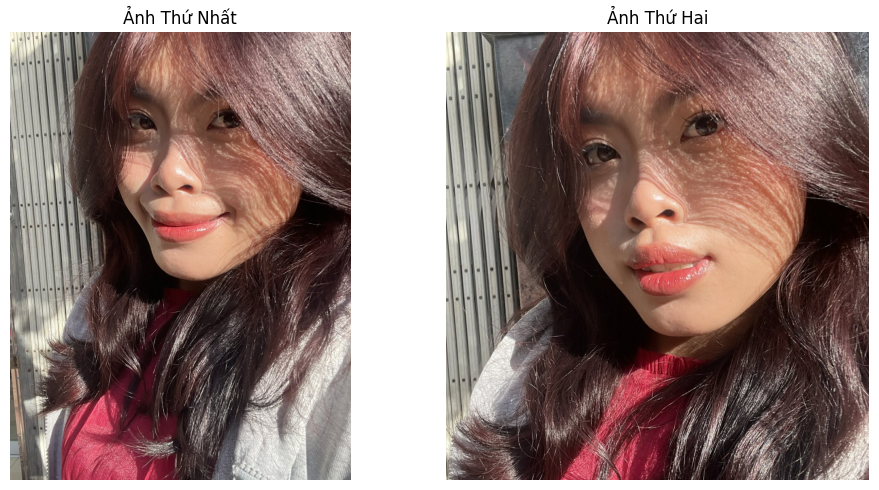

In [8]:
# Trực quan hóa ảnh 
plt.figure(figsize=(10, 5))

    # Ảnh thứ nhất
plt.subplot(1, 2, 1)
plt.imshow(img_money1)
plt.title('Ảnh Thứ Nhất')
plt.axis('off') # Ẩn trục tọa độ

# Ảnh thứ hai
plt.subplot(1, 2, 2)
plt.imshow(img_money2)
plt.title('Ảnh Thứ Hai')
plt.axis('off')
plt.tight_layout()
plt.show()

### 1. **Model Facenet**

In [9]:
# function get embedding (dùng để số hóa một khuôn mặt thành một vector số)
def get_embedding(img_path):
    result = DeepFace.represent(
        img_path=img_path,
        model_name='Facenet',
        enforce_detection=False
    )
    return np.array(result[0]["embedding"])

In [10]:
embedding_1 = get_embedding(img_money1)
print("Embedding của ảnh thứ nhất:\n", embedding_1)

Embedding của ảnh thứ nhất:
 [-0.31386676 -0.72364748 -0.33117092 -0.18512431  0.39307031 -0.50796992
 -0.28500345  0.13274421  0.77422339 -0.1495291   0.2463021  -0.21653165
  0.37168127 -0.82022703  0.01723191 -0.72521353  0.20930976  0.14883895
  0.20941615 -0.76482266 -0.23841467  0.24691333 -0.65542674  0.55687052
  0.45767727 -0.27571094  0.70087641 -0.19765717 -0.1849      0.10275721
 -0.67333692  0.43380392 -0.03680386  0.23922685  0.77962875  0.00483705
  0.98472583 -0.90951544 -0.24229071 -0.31168777  0.23823161  1.15379393
  0.20945688  0.35507068 -0.21377076 -0.27055177  0.06307046 -0.37722823
  0.71476352  0.47886899 -0.54774183  0.16708085  0.12510243 -0.73380458
 -0.28629252  0.21709977  1.11066628 -0.37367341 -0.59741116 -0.85768145
 -0.12816396  0.27122736  0.0667794   0.94187576  0.21069369  1.70156384
  0.28710473  0.42931604  0.34905899 -1.12075901  0.69415504 -0.76376987
 -0.44466209 -0.99491322  0.71727771 -0.73727137 -0.43062598  0.10756704
 -0.78683501 -0.276677

In [11]:
print(f"Dạng dữ liệu: {type(embedding_1)}")
print(f"Số lượng đặc trưng (độ dài vector): {len(embedding_1)}")
print(f"5 giá trị đầu tiên: {embedding_1[:5]}")

Dạng dữ liệu: <class 'numpy.ndarray'>
Số lượng đặc trưng (độ dài vector): 128
5 giá trị đầu tiên: [-0.31386676 -0.72364748 -0.33117092 -0.18512431  0.39307031]


Biểu đồ đặc trưng của khuôn mặt (Face Signature):


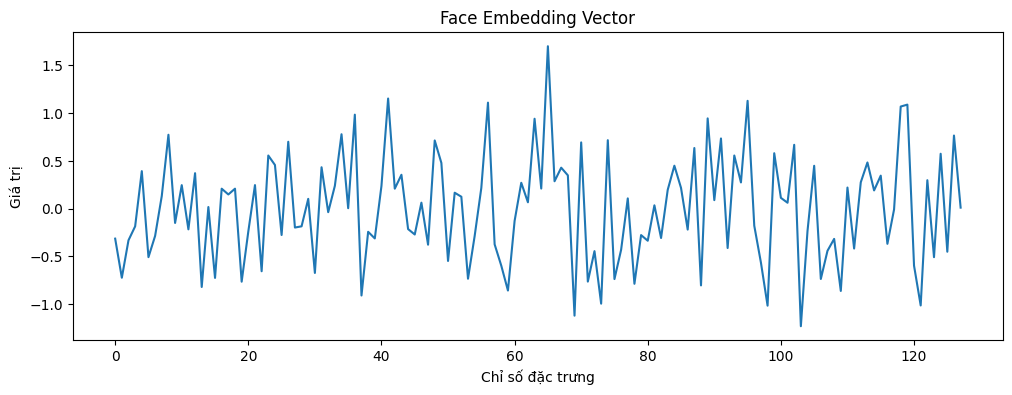

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(embedding_1)
print("Biểu đồ đặc trưng của khuôn mặt (Face Signature):")
plt.title("Face Embedding Vector")
plt.xlabel("Chỉ số đặc trưng")
plt.ylabel("Giá trị")
plt.show()

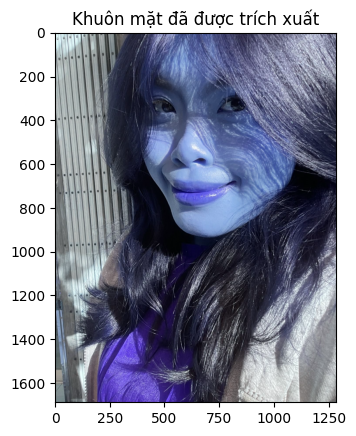

In [15]:
# Cách sửa: Bỏ target_size
face_detected = DeepFace.extract_faces(
    img_path=img_money1, 
    enforce_detection=False,
    detector_backend='mtcnn' # Bạn có thể chọn 'retinaface', 'mtcnn', v.v.
)

# Hiển thị khuôn mặt
# Lưu ý: face_detected là một danh sách, mỗi phần tử có key là "face"
plt.imshow(face_detected[0]['face'])
plt.title("Khuôn mặt đã được trích xuất")
plt.show()

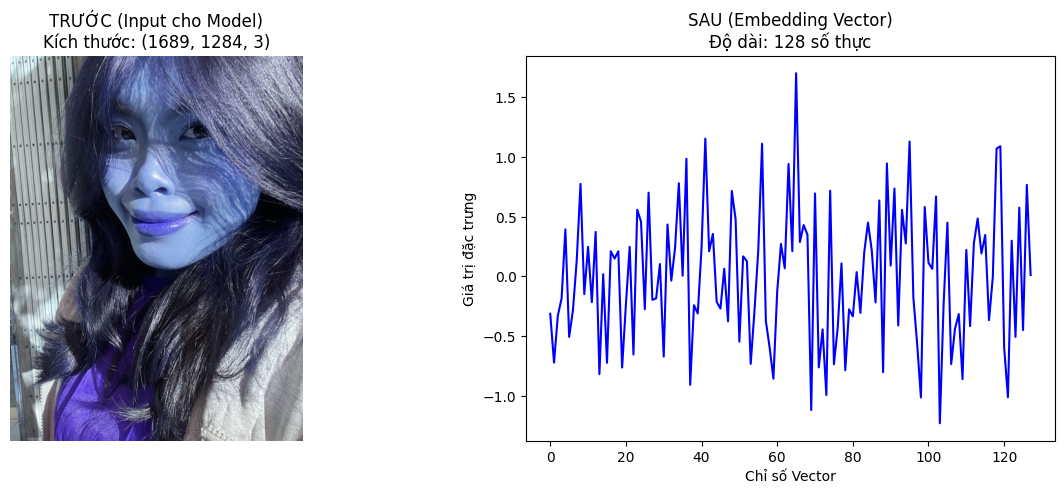

In [16]:
# 1. Lấy ảnh đã cắt (đây là bước trung gian AI thực hiện)
face_objs = DeepFace.extract_faces(img_path=img_money1, enforce_detection=False)
face_img = face_objs[0]['face']

# 2. Lấy vector embedding (kết quả sau cùng)
embedding_1 = get_embedding(img_money1)

# 3. Vẽ đồ thị so sánh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bên trái: Ảnh AI nhìn thấy
ax1.imshow(face_img)
ax1.set_title(f"TRƯỚC (Input cho Model)\nKích thước: {face_img.shape}")
ax1.axis('off')

# Bên phải: Vector đặc trưng
ax2.plot(embedding_1, color='blue')
ax2.set_title(f"SAU (Embedding Vector)\nĐộ dài: {len(embedding_1)} số thực")
ax2.set_xlabel("Chỉ số Vector")
ax2.set_ylabel("Giá trị đặc trưng")

plt.show()

In [10]:
embedding_2 = get_embedding(img_money2)
print("Embedding của ảnh thứ hai:\n", embedding_2)

Embedding của ảnh thứ hai:
 [-0.28785944 -1.54304624 -0.1675002   0.05695603 -1.51130807 -0.14078063
 -0.86280811 -0.98197073  0.47916517  1.00978529 -0.39593765 -0.03014466
  0.1856073  -1.21194839 -0.73613155  0.40053296  0.85527444 -0.34631097
  0.08041523  0.28032637  0.87135398  0.35192513 -0.14064783 -0.39184478
  0.6022436   0.49027267  0.99852455 -0.36272651  0.41139525 -0.87192857
 -0.44216773 -0.038246    0.22865297 -0.1017461   1.81646061  0.7018463
 -0.03673302  0.21449754  0.59152448  0.46756801  0.06523083  1.29635644
 -0.49855396 -0.35005251 -0.27830958 -0.10831091 -0.02809237 -0.05534062
 -0.70921499 -0.38247335 -1.83303595 -0.49232394  0.3861669  -0.15479875
  0.27363151 -0.10441046  2.11370111  0.86239928 -0.97750664 -2.35033441
  0.1602245  -0.29137033 -1.32441783  0.39312053 -0.46749824  1.74763608
  1.96377099  0.37120673  0.46042949 -1.10858309  0.32465026 -0.00572985
 -1.00783789 -0.95147228  0.87747991 -0.01677386 -0.14341374 -0.09253463
  0.04190294 -0.75917929

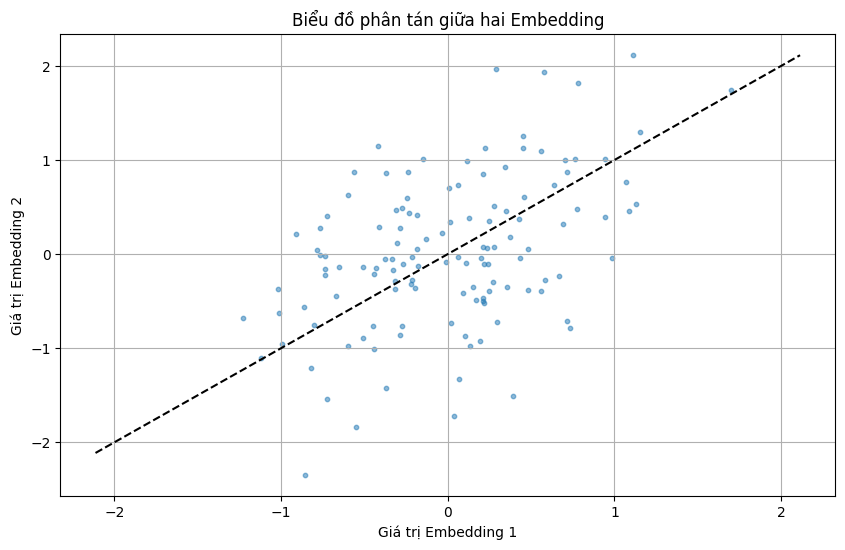

In [13]:

plt.figure(figsize=(10, 6))
plt.scatter(embedding_1, embedding_2, alpha=0.5, s=10)

# Vẽ đường chéo lý tưởng (y = x)
# Nếu hai ảnh giống hệt nhau, mọi điểm sẽ nằm trên đường này
limit = max(embedding_1.max(), embedding_2.max())
plt.plot([-limit, limit], [-limit, limit], color='black', linestyle='--')
plt.title('Biểu đồ phân tán giữa hai Embedding')
plt.xlabel('Giá trị Embedding 1')
plt.ylabel('Giá trị Embedding 2')
plt.grid(True)
plt.show()

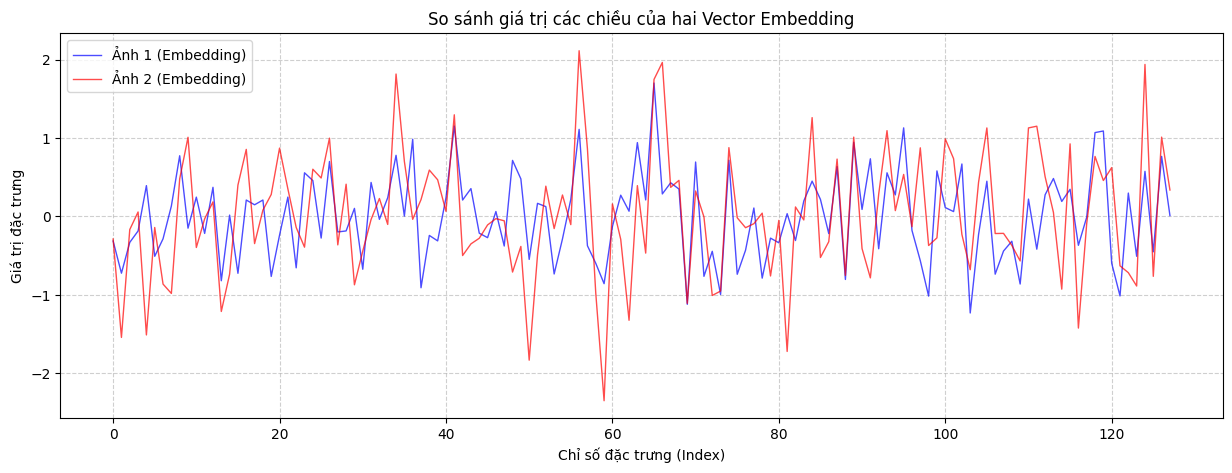

In [11]:
plt.figure(figsize=(15, 5))

# Vẽ đường cho embedding 1
plt.plot(embedding_1, label='Ảnh 1 (Embedding)', alpha=0.7, color='blue', linewidth=1)

# Vẽ đường cho embedding 2
plt.plot(embedding_2, label='Ảnh 2 (Embedding)', alpha=0.7, color='red', linewidth=1)

plt.title('So sánh giá trị các chiều của hai Vector Embedding')
plt.xlabel('Chỉ số đặc trưng (Index)')
plt.ylabel('Giá trị đặc trưng')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()